# MRCD Framework - Test and Inference Pipeline

**Note**: This notebook is for testing the MRCD pipeline using a pre-trained SLM model.
**For training the SLM model, use: `SLM_training_tw1516.ipynb`**

**Cấu trúc:**
1. **Thiết lập Môi trường**: Thư viện, cấu hình runtime, và đường dẫn dữ liệu.
2. **Prompt Builders + Thiết lập LLM Local**: Prompt dùng chung và cấu hình model/LLM handler.
3. **Triển khai Module Cốt lõi**: Label Synonyms, Retrieval (Demo + Fact), Knowledge Agent.
4. **Load Pre-trained SLM**: Tải model đã huấn luyện.
5. **Pipeline MRCD**: Điều phối retrieval, selection, và vòng lặp multi-round learning.
6. **Test và Đánh giá**: Chạy test set và đo hiệu năng framework.

## 1. Environment Setup

In [ ]:
%pip install ddgs rank_bm25 wikipedia transformers accelerate sentencepiece beautifulsoup4 curl_cffi sentence-transformers

In [2]:
# --- 1. Environment Setup ---
import os
import sys
import json
import re
import random
import math
import warnings
import requests
import io
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod
from typing import Optional, List, Dict
from concurrent.futures import ThreadPoolExecutor, as_completed

# Suppress warnings
warnings.filterwarnings('ignore')

try:
    import torch
    import torch.nn.functional as F
    import numpy as np
    import pandas as pd
    from ddgs import DDGS
    from rank_bm25 import BM25Okapi
    import wikipedia
    from transformers import (
        AutoModelForCausalLM,
        AutoTokenizer,
        RobertaTokenizer,
        RobertaForSequenceClassification,
        get_linear_schedule_with_warmup,
    )
    from torch.optim import AdamW
    from torch.utils.data import Dataset, DataLoader
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    from tqdm.auto import tqdm
except ImportError as e:
    print(f" Missing library: {e}. Please install necessary packages.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Using device: {device}")

 Using device: cuda


In [3]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

# Replace "YOUR_HF_TOKEN" with your actual token
login(token=user_secrets.get_secret("HF_TOKEN"))
print("login")

login


In [4]:
# --- Data Paths Configuration ---
DATA_DIR = r"/kaggle/input/datasets/chinhde/twitter15-16"
TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
VAL_CSV = os.path.join(DATA_DIR, "val.csv")
TEST_CSV = os.path.join(DATA_DIR, "test.csv")
MODEL_PATH = "/kaggle/input/models/chinhde/roberta-fine-v2/pytorch/default/1"

print(f"Data Directory: {DATA_DIR}")
print(f"Train CSV: {TRAIN_CSV}")
print(f"Val CSV: {VAL_CSV}")
print(f"Test CSV: {TEST_CSV}")

Data Directory: /kaggle/input/datasets/chinhde/twitter15-16
Train CSV: /kaggle/input/datasets/chinhde/twitter15-16/train.csv
Val CSV: /kaggle/input/datasets/chinhde/twitter15-16/val.csv
Test CSV: /kaggle/input/datasets/chinhde/twitter15-16/test.csv


## 2. Triển khai Các Module

### 2.1 Prompt Builders
Tập trung các hàm build prompt dùng chung cho retrieval và classification.

In [5]:
# --- Prompt Builders & Output Parsers ---
def build_dual_extraction_prompt(text: str) -> str:
    prompt = (
        "You are an expert Fact-Checking Extraction Agent. Your task is to process a raw news text "
        "and generate two outputs simultaneously for a Two-Stage Retrieval System.\n\n"
        "TASK 1: WIKI ENTITIES (For Knowledge Retrieval)\n"
        "Extract 1 to 4 core named entities (People, Organizations, Locations, Events) from the text "
        "that are crucial for verifying the claim and are highly likely to have a Wikipedia page.\n\n"
        "TASK 2: NEUTRAL QUERY (For Fact-Check Search)\n"
        "Generate a single, concise search query to retrieve factual articles. "
        "STRICT RULES: Focus ONLY on factual core subjects. REMOVE all clickbait, sensational, "
        "or emotional words (e.g., 'breaking', 'urgent', 'cure', 'secret'). "
        "DO NOT use quotation marks (\"\") or any search operators.\n\n"
        "OUTPUT FORMAT:\n"
        "Return ONLY a valid JSON object. Do NOT wrap in markdown tags (like ```json), no preamble, no explanations.\n"
        "Schema: {\"entities\": [\"entity_1\", \"entity_2\"], \"query\": \"query\"}\n\n"
        f"Input text: {text}"
    )
    return prompt

def build_classification_prompt(
    text: str,
    knowledge_k: str,
    demos: list,
    real_labels: list,
    fake_labels: list,
) -> str:
    all_labels = real_labels + fake_labels
    all_labels_list = ", ".join(all_labels)

    # 1. HEADER
    header = f"""You are an advanced AI fake news detector.

BACKGROUND KNOWLEDGE:
{knowledge_k}

INSTRUCTIONS:
Classify the following news article by selecting EXACTLY ONE label from the provided label list.
Do not create new labels. Do not output explanations.

Possible Labels: [{all_labels_list}]

EXAMPLES:"""

    # 2. FEW-SHOT DEMOS
    examples = ""
    if demos:
        for i, demo in enumerate(demos, start=1):
            label_str = demo.get("label", "Unknown")
            text_demo = demo.get("text", "")[:1000].strip()
            examples += f"\n[Example {i}]\nText: \"{text_demo}...\"\nLabel: {label_str}\n"
    else:
        examples += "\n(No examples provided)\n"

    # 3. TAIL & TARGET
    tail = f"""
----------------------------------------
TARGET ARTICLE TO CLASSIFY:
Text: "{text.strip()}"

OUTPUT FORMAT:
Return ONLY one label string from the Possible Labels list. Do NOT wrap it in quotes.
Label:"""

    return header + examples + tail

def _normalize_label_text(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip().lower())

def parse_binary_label(
    llm_response: str,
    real_labels: list,
    fake_labels: list,
    default_fake: int = 1,
    return_matched_label: bool = False,
):
    text = _normalize_label_text(llm_response)
    text = text.replace("```json", "").replace("```", "").strip()

    candidates = [
        *[(lbl, 0) for lbl in real_labels],
        *[(lbl, 1) for lbl in fake_labels],
    ]
    candidates = sorted(candidates, key=lambda x: len(x[0]), reverse=True)

    for label, binary in candidates:
        if text == _normalize_label_text(label):
            return (binary, label) if return_matched_label else binary

    for label, binary in candidates:
        lnorm = re.escape(_normalize_label_text(label))
        if re.search(rf"(^|[^a-z0-9]){lnorm}([^a-z0-9]|$)", text):
            return (binary, label) if return_matched_label else binary

    first_token = re.split(r"\s+|[,:;.!?]", text)[0].strip()
    for label, binary in candidates:
        if first_token and first_token == _normalize_label_text(label):
            return (binary, label) if return_matched_label else binary

    return (default_fake, None) if return_matched_label else default_fake

### 2.2 Xử lý LLM (LLM Handler)
- **`BaseLLM`**: Lớp cơ sở trừu tượng cho các LLM.
- **`QwenLLM`**: Triển khai sử dụng model `Qwen/Qwen3.5-9B` chạy local qua Hugging Face Transformers.


In [6]:
# --- Qwen Configuration ---
# QWEN_MODEL_NAME = "Qwen/Qwen3.5-9B"
QWEN_MODEL_NAME = "Qwen/Qwen3-4B-Instruct-2507"
# QWEN_MODEL_NAME = "Qwen/Qwen3-14B"
# QWEN_MODEL_NAME = "meta-llama/Meta-Llama-3-8B-Instruct"


QWEN_MAX_NEW_TOKENS = 128
QWEN_MAX_OUTPUT_TOKENS_EXTRACTION = 96
QWEN_MAX_OUTPUT_TOKENS_CLASSIFICATION = 12
QWEN_TEMPERATURE = 0.0
QWEN_TOP_P = 1.0

print(f" LLM backend: {QWEN_MODEL_NAME}")

 LLM backend: Qwen/Qwen3-4B-Instruct-2507


In [7]:
# --- LLM Handler ---
class BaseLLM(ABC):
    @abstractmethod
    def generate_text(self, prompt: str, max_output_tokens: int = QWEN_MAX_NEW_TOKENS) -> str:
        pass

class QwenLLM(BaseLLM):
    def __init__(self, model_name: str = QWEN_MODEL_NAME):
        self.model_name = model_name
        self.model = None
        self.tokenizer = None
        # self.context_window = None
        self._load_model()

    def _load_model(self):
        try:
            self.tokenizer = AutoTokenizer.from_pretrained(self.model_name)
            if self.tokenizer.pad_token_id is None:
                self.tokenizer.pad_token = self.tokenizer.eos_token

            self.model = AutoModelForCausalLM.from_pretrained(
                self.model_name,                
                torch_dtype="auto",
                device_map="auto",
            )
            self.model.generation_config.pad_token_id = self.tokenizer.pad_token_id

            tokenizer_limit = getattr(self.tokenizer, "model_max_length", None)
            if tokenizer_limit is None or tokenizer_limit <= 0:
                # self.context_window = 128000
                print(
                    f" Warning: Tokenizer max length is {tokenizer_limit}. "
                )
            # else:
            #     self.context_window = int(tokenizer_limit)

            print(f" Loaded LLM: {self.model_name}")
            # print(f" Context window: {self.context_window} tokens")
        except Exception as e:
            self.model = None
            self.tokenizer = None
            raise RuntimeError(f"Failed to load {self.model_name}: {e}")

    def generate_text(self, prompt: str, max_output_tokens: int = QWEN_MAX_NEW_TOKENS) -> str:
        if self.model is None or self.tokenizer is None:
            raise RuntimeError("Qwen model is not initialized.")

        messages = [{"role": "user", "content": prompt}]
        text = self.tokenizer.apply_chat_template(
            messages,
            tokenize=False,            
            add_generation_prompt=True,
        )



        inputs = self.tokenizer(
            [text],
            return_tensors="pt",
        ).to(self.model.device)

        with torch.inference_mode():
            output_ids = self.model.generate(
                **inputs,
                max_new_tokens=max(1, int(max_output_tokens)),
                do_sample=False,
                temperature=QWEN_TEMPERATURE,
                top_p=QWEN_TOP_P,
                pad_token_id=self.tokenizer.pad_token_id,
                eos_token_id=self.tokenizer.eos_token_id,
            )

        gen_only_ids = [
            out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)
        ]
        response = self.tokenizer.batch_decode(gen_only_ids, skip_special_tokens=True)[0]
        return response.strip()

# Global Accessor
_current_llm = None

def get_llm():
    global _current_llm
    if _current_llm is None:
        _current_llm = QwenLLM()
    return _current_llm
get_llm()

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

 Loaded LLM: Qwen/Qwen3-4B-Instruct-2507


### 2.3 Label Synonyms for Demonstrations
Các nhãn đồng nghĩa dùng để gán pseudo-label cho bài mẫu, giúp giảm hiện tượng LLM bắt chước nhãn nhị phân trực tiếp.

In [8]:
REAL_NEWS_LABELS = [
    # Basic
    # "Real",
    "Authentic",
    "Reliable",
    "True",
    "Genuine",
    "Credible",
    "Fact-based",
    "Verified",
    "Accurate",

    # Nuanced / Descriptive
    "Trustworthy",
    "Factual",
    "Legitimate",
    "Proven",
    "Substantiated",
    "Valid",
    "Confirmed",
    "Authoritative",
    "Honest",
    "Objective"
]

FAKE_NEWS_LABELS = [
    # Basic
    # "Fake",
    "Hoax",
    "False",
    "Fabricated",
    "Untrue",
    "Misleading",
    "Bogus",
    "Inaccurate",

    # Nuanced / Descriptive
    "Dubious",
    "Deceptive",
    "Unverified",
    "Rumor",
    "Satire",
    "Propaganda",
    "Manipulated",
    "Distorted",
    "Baseless",
    "Phony",
    "Clickbait",
    "Disinformation",
    "Misinformation"
]

ALL_LABELS = REAL_NEWS_LABELS + FAKE_NEWS_LABELS

# Use synonym-only pseudo labels for demonstrations
REAL_DEMO_LABELS = [x for x in REAL_NEWS_LABELS if x.lower() != "real"]
FAKE_DEMO_LABELS = [x for x in FAKE_NEWS_LABELS if x.lower() != "fake"]
DEMO_LABELS = REAL_DEMO_LABELS + FAKE_DEMO_LABELS

def generate_label(text):
    """Randomly assigns a synonym label for retrieved demonstrations."""
    return random.choice(DEMO_LABELS)

In [9]:
import re
import unicodedata
from urllib.parse import quote_plus
    
def clean_query(text: str) -> str:
 
    text = unicodedata.normalize("NFKC", text)
    
    text = re.sub(r"[^\w\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

def truncate_text(text: str, max_length: int = 50) -> str:
    if len(text) <= max_length:
        return text
    
    cut_pos = text.rfind(' ', 0, max_length)
    
    if cut_pos == -1:
        return text[:max_length] + "..."
    
    return text[:cut_pos] + "..."

### 2.4 Retrieval Module
Tách riêng thành 2 nhánh độc lập để dễ quản lý và bám sát kiến trúc:
- **Cell Nhánh 1 - Demonstration Retrieval**: Bing + static corpus + BM25 top-k.
- **Cell Nhánh 2 - Knowledge Retrieval (Dual Engine)**: LLM phân tích (entities + query) -> Wiki + Trusted sources -> crawl + chunk reranking.

#### 2.4.1 Branch 1 - Demonstration Retrieval

In [10]:
import csv
import os

def log_retrieval_to_csv(func_name, query, title, url, snippet):
    filepath = 'd:/Study_space/Ki8/PBL7/tw1516/31032026/retrieval_debug.csv'
    file_exists = os.path.isfile(filepath)
    try:
        with open(filepath, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(['source_function', 'query', 'title', 'url', 'snippet'])
            writer.writerow([func_name, query, title, url, snippet])
    except Exception:
        pass

# --- Branch 1: Demonstration Retrieval (Bing + Corpus + BM25) ---

# News Corpus Handling (Remote CSV)
AG_NEWS_URL = "https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv"

def load_news_corpus(url=AG_NEWS_URL):
    """Downloads AG News CSV and loads it as a list of text documents."""
    print(f" Downloading News Corpus from {url}...")
    try:
        response = requests.get(url)
        response.raise_for_status()

        csv_content = io.StringIO(response.text)
        df = pd.read_csv(csv_content, header=None, names=["class", "title", "desc"])
        corpus_texts = (df["title"] + " " + df["desc"]).tolist()

        print(f" Loaded {len(corpus_texts)} documents from AG News.")
        return corpus_texts
    except Exception as e:
        print(f" Error downloading corpus: {e}")
        return []

def search_news(query: str, max_results: int = 10):
    """Search latest news snippets for demonstration retrieval."""
    query = clean_query(query)
    query = truncate_text(query, max_length=50)

    news_items = []
    try:
        with DDGS(timeout=20) as ddgs:
            results_gen = ddgs.news(
                query=query,
                region="wt-wt",
                safesearch="off",
                timelimit=None,
                max_results=max_results,
                backend="bing",
            )

            for i, result in enumerate(results_gen):
                if i >= max_results:
                    break

                title = result.get("title", "")
                body = result.get("body", "")
                news_items.append(f"{title}\n{body}")
                url = result.get("url", result.get("href", ""))
                log_retrieval_to_csv("search_news", query, title, url, body)
    except Exception:
        pass
    return news_items

def retrieve_demonstrations(query: str, corpus_items: list, k: int = 4):
    """Use BM25 to fetch top-k demonstrations from retrieved corpus."""
    if not corpus_items:
        return []

    tokenized_corpus = [doc.lower().split() for doc in corpus_items]
    bm25 = BM25Okapi(tokenized_corpus)
    scores = bm25.get_scores(query.lower().split())

    scored_indices = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    top_k = [idx for idx, _ in scored_indices[:k]]

    demonstrations = []
    for i in top_k:
        content = corpus_items[i]
        demonstrations.append(
            {
                "text": content,
                "label": generate_label(content),
                "source": "Bing/Retrieved",
            }
        )
    return demonstrations

#### 2.4.2 Branch 2 - Knowledge Retrieval (Dual Engine)
Luồng xử lý:
1. Dùng LLM phân tích đầu vào để trả về **entities** và **query** cùng lúc.
2. Truy xuất trusted domains bằng query.
3. Crawl nội dung trang, chunk theo câu.
4. Dùng Cross-Encoder chọn top chunk có độ liên quan cao nhất (K_fact).

In [11]:
import csv
import os

def log_retrieval_to_csv(func_name, query, title, url, snippet):
    filepath = 'd:/Study_space/Ki8/PBL7/tw1516/31032026/retrieval_debug.csv'
    file_exists = os.path.isfile(filepath)
    try:
        with open(filepath, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            if not file_exists:
                writer.writerow(['source_function', 'query', 'title', 'url', 'snippet'])
            writer.writerow([func_name, query, title, url, snippet])
    except Exception:
        pass

# --- Branch 2: Knowledge Retrieval (LLM analysis + Crawl + Rerank) ---

from bs4 import BeautifulSoup
from curl_cffi import requests as curl_requests
from sentence_transformers import CrossEncoder

TRUST_DOMAINS = [
    "apnews.com",
    "reuters.com",
    "afp.com",
    "factcheck.org",
    "snopes.com",
    "fullfact.org",
    "who.int",
    "cdc.gov",
    "npr.org",
    "pbs.org",
    "theguardian.com",
    "theconversation.com",
]

def analyze_claim_entities_and_query(text: str) -> dict:
    """Use LLM once to return entities and a search query."""
    prompt = build_dual_extraction_prompt(text)
    fallback = {
        "entities": [],
        "query": truncate_text(clean_query(text), max_length=80),
    }

    try:
        llm = get_llm()
        raw = llm.generate_text(prompt, max_output_tokens=QWEN_MAX_OUTPUT_TOKENS_EXTRACTION)
        clean = raw.replace("```json", "").replace("```", "").strip()
        match = re.search(r"\{.*\}", clean, re.DOTALL)
        if match:
            clean = match.group(0)

        data = json.loads(clean)
        entities = data.get("entities", []) if isinstance(data, dict) else []
        query = data.get("query", "") if isinstance(data, dict) else ""

        normalized_entities = []
        for item in entities:
            if isinstance(item, str) and item.strip():
                normalized_entities.append(item.strip())
            elif isinstance(item, dict) and item.get("entity"):
                normalized_entities.append(str(item.get("entity", "")).strip())

        if not query:
            query = fallback["query"]
        else:
            query = truncate_text(clean_query(query), max_length=80)

        return {
            "entities": normalized_entities,
            "query": query,
        }
    except Exception:
        return fallback

def build_trusted_domain_query(domains: list) -> str:
    if not domains:
        return ""
    return "(" + " OR ".join([f"site:{d}" for d in domains]) + ")"

def scrape_full_article(url: str):
    """Crawl article body and keep high-signal paragraphs."""
    browsers = ["chrome", "chrome110", "edge99", "safari15_3"]
    browser_choice = random.choice(browsers)

    try:
        response = curl_requests.get(url, impersonate=browser_choice, timeout=15)
        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.text, "html.parser")
        for element in soup(["script", "style", "nav", "footer", "header", "aside", "form", "button", "iframe"]):
            element.decompose()

        paragraphs = soup.find_all("p")
        cleaned_paragraphs = []
        for p in paragraphs:
            text = p.get_text(separator=" ", strip=True)
            if len(text.split()) > 8:
                cleaned_paragraphs.append(text)

        raw_text = " ".join(cleaned_paragraphs)
        raw_text = re.sub(r"http[s]?://\S+", "", raw_text)
        raw_text = re.sub(r"www\.\S+", "", raw_text)
        raw_text = re.sub(r"\[.*?\]", "", raw_text)
        article_text = re.sub(r"\s+", " ", raw_text).strip()

        if not article_text:
            return None
        return article_text
    except Exception:
        return None

import re

def chunk_text_by_sentences(text: str, max_words: int = 300, overlap_sentences: int = 1):
    """Split text into semantic chunks using sentence boundaries."""
    if not text:
        return []

    # Tách câu (Lưu ý: sẽ bị ngáo với các từ viết tắt có dấu chấm như Mr., Dr.)
    sentences = re.split(r"(?<=[.!?])\s+", text)
    sentences = [s.strip() for s in sentences if s.strip()]

    chunks = []
    current_chunk = []
    current_word_count = 0
    i = 0

    while i < len(sentences):
        sentence = sentences[i]
        sentence_words = len(sentence.split())

        # Xử lý ngoại lệ: 1 câu đơn lẻ mà dài hơn cả max_words
        if sentence_words > max_words:
            if current_chunk:
                chunks.append(" ".join(current_chunk))
                current_chunk = []
                current_word_count = 0
            chunks.append(sentence)
            i += 1
            continue

        # Nếu nhét vừa -> Cho vào current_chunk
        if current_word_count + sentence_words <= max_words:
            current_chunk.append(sentence)
            current_word_count += sentence_words
            i += 1
        else:
            # Nếu không nhét vừa -> Lưu chunk cũ lại
            chunks.append(" ".join(current_chunk))

            # XỬ LÝ OVERLAP THÔNG MINH HƠN:
            if overlap_sentences > 0:
                # Cứ lấy tối đa số câu overlap có thể (Python tự handle list ngắn)
                current_chunk = current_chunk[-overlap_sentences:]
                current_word_count = sum(len(s.split()) for s in current_chunk)

                # Rút bớt từng câu ở đầu ra nếu vẫn lố max_words (gọt cho vừa)
                while current_chunk and (current_word_count + sentence_words > max_words):
                    removed_sentence = current_chunk.pop(0)
                    current_word_count -= len(removed_sentence.split())
            else:
                current_chunk = []
                current_word_count = 0
            
            # Note: Không gọi `i += 1` ở đây để vòng lặp sau nhét lại câu `sentence` vào chunk mới

    # Vét nốt chunk cuối cùng
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks

_fact_ranker = None

def get_fact_ranker():
    global _fact_ranker
    if _fact_ranker is None:
        _fact_ranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
    return _fact_ranker
get_fact_ranker()

def retrieve_fact_evidence(raw_query: str, max_urls: int = 12, top_k_chunks: int = 3, similarity_threshold: float = 4.0):
    """Trusted-domain retrieval + crawl + reranking to keep top relevant chunks."""
    analysis = analyze_claim_entities_and_query(raw_query)
    query = analysis.get("query", truncate_text(clean_query(raw_query), max_length=80))

    trusted_domains = build_trusted_domain_query(TRUST_DOMAINS)
    search_query = f"{query} {trusted_domains}".strip()

    results = []
    documents = []

    try:
        with DDGS(timeout=20) as ddgs:
            results_gen = ddgs.text(search_query, backend="bing", max_results=max_urls)
            for i, r in enumerate(results_gen):
                if i >= max_urls:
                    break
                title = str(r.get("title", "")).strip()
                url = str(r.get("href", "")).strip()
                snippet = str(r.get("body", "")).strip()
                results.append({"title": title, "url": url, "snippet": snippet})
                log_retrieval_to_csv("retrieve_fact_evidence", search_query, title, url, snippet)
    except Exception:
        results = []

    for r in results:
        content = scrape_full_article(r["url"])
        if not content or len(content.split()) < 30:
            content = r.get("snippet", "")
        if not content:
            continue
        documents.append(
            {
                "title": r["title"],
                "url": r["url"],
                "content": content,
            }
        )

    if not documents:
        return {
            "analysis": analysis,
            "top_chunks": [],
        }

    ranker = get_fact_ranker()
    scored_chunks = []

    for doc in documents:
        chunks = chunk_text_by_sentences(doc["content"], max_words=300, overlap_sentences=1)
        if not chunks:
            continue

        pairs = [[raw_query, chunk] for chunk in chunks]
        scores = ranker.predict(pairs)

        for idx, score in enumerate(scores):
            # CHỈ THÊM chunk nếu score >= threshold
            if float(score) >= similarity_threshold:
                scored_chunks.append(
                    {
                        "score": float(score),
                        "chunk_text": chunks[idx],
                        "title": doc["title"],
                        "url": doc["url"],
                        "source": "trusted_crawled",
                    }
                )


    scored_chunks.sort(key=lambda x: x["score"], reverse=True)
    top_chunks = scored_chunks[:top_k_chunks]

    return {
        "analysis": analysis,
        "top_chunks": top_chunks,
    }

def format_fact_knowledge(top_chunks: list) -> str:
    if not top_chunks:
        return "No trusted fact evidence found."

    lines = []
    for i, item in enumerate(top_chunks, start=1):
        lines.append(
            f"[F{i}] score={item['score']:.4f} | {item['title']} | {item['chunk_text']} | {item['url']}"
        )
    return "\n".join(lines)

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

In [12]:
print(search_news("craigslist ad: get paid $15 an hour to protest"))

["Fact Check: 'STOP TRUMP' Craigslist ad recruiting paid protesters isn't from January 2026\nA photo circulating online authentically showed a Craigslist ad from January 2026 recruiting paid protesters to demonstrate against U.S. President Donald Trump. And every time this happens, innocent ...", "'Stop Trump' Craigslist ad recruiting paid protesters isn't from January 2026\nA photo circulating online authentically showed a Craigslist ad from January 2026 recruiting paid protesters to demonstrate against U.S. President Donald Trump. Rating: Miscaptioned (About this rating ...", "'STOP TRUMP' Craigslist ad recruiting paid protesters isn't from January 2026\nA photo circulating online authentically showed a Craigslist ad from January 2026 recruiting paid protesters to demonstrate against U.S. President Donald Trump. The alleged advertisement was offering ..."]


### 2.5 Knowledge Agent (Orchestration)
Ghép kết quả từ Nhánh 2 thành gói tri thức cuối cùng:
- **`K_wiki`**: kiến thức bách khoa theo thực thể.
- **`K_fact`**: bằng chứng từ nguồn tin cậy, đã crawl và chọn top chunk liên quan nhất.
- Cache theo từng pipeline run để giảm số lần truy xuất lặp lại.

#### 2.5.1 Knowledge Agent Implementation
Cell này điều phối hợp nhất K_wiki và K_fact, đồng thời cache kết quả cho từng event trong pipeline.

In [13]:
# --- Knowledge Agent Orchestration + In-Memory Cache (Per Pipeline Run) ---

def query_wikipedia(entity: str, lang: str = "en") -> str:
    try:
        wikipedia.set_lang(lang)
        return wikipedia.summary(entity, auto_suggest=True)
    except Exception:
        return "Not found"

def extract_wiki_knowledge_from_entities(entities: list) -> dict:
    """Build entity definitions from extracted entities (English source)."""
    res = {}
    for ent in entities:
        if isinstance(ent, str) and ent.strip():
            ent_text = ent.strip()
        elif isinstance(ent, dict) and ent.get("entity"):
            ent_text = str(ent.get("entity", "")).strip()
        else:
            continue

        summ = query_wikipedia(ent_text, "en")
        if "Not found" not in summ:
            res[ent_text] = summ
    return res

def format_verified_reports(top_chunks: list) -> str:
    if not top_chunks:
        return "- Title: No verified report found\n\n- Key Information: No trusted fact evidence found."

    lines = []
    for item in top_chunks:
        title = item.get("title", "Unknown source")
        key_info = item.get("chunk_text", "")
        lines.append(f"- Title: {title}")
        lines.append("")
        lines.append(f"- Key Information: {key_info}")
        lines.append("")
    return "\n".join(lines).strip()

def format_entity_definitions(wiki_res: dict) -> str:
    if not wiki_res:
        return "- Entity: N/A\n\n- Definition: No entity definition found."

    lines = []
    for entity, definition in wiki_res.items():
        lines.append(f"- Entity: {entity}")
        lines.append("")
        lines.append(f"- Definition: {definition}")
        lines.append("")
    return "\n".join(lines).strip()

def build_knowledge_bundle(text: str, fact_top_k: int = 3) -> dict:
    """Return compact K context only, formatted for MRCD prompt input."""
    fact_output = retrieve_fact_evidence(
        raw_query=text,
        max_urls=12,
        top_k_chunks=fact_top_k,
    )
    analysis = fact_output.get("analysis", {})
    entities = analysis.get("entities", [])

    wiki_res = extract_wiki_knowledge_from_entities(entities)
    fact_chunks = fact_output.get("top_chunks", [])

    verified_reports = format_verified_reports(fact_chunks)
    entity_definitions = format_entity_definitions(wiki_res)

    combined_text = (
        "<VERIFIED_REPORTS>\n\n"
        f"{verified_reports}\n\n"
        "</VERIFIED_REPORTS>\n\n"
        "<ENTITY_DEFINITIONS>\n\n"
        f"{entity_definitions}\n\n"
        "</ENTITY_DEFINITIONS>"
    )

    return {"combined_text": combined_text}

def get_cached_knowledge_bundle_local(text: str, cache: dict, fact_top_k: int = 3) -> dict:
    """Cache compact K context only within current pipeline run."""
    if cache is None:
        return build_knowledge_bundle(text, fact_top_k=fact_top_k)

    cache_key = f"{text}||fact_top_k={fact_top_k}"
    if cache_key in cache:
        return cache[cache_key]

    bundle = build_knowledge_bundle(text, fact_top_k=fact_top_k)
    cache[cache_key] = bundle
    return bundle

In [14]:
sample_claim = "craigslist ad: get paid $15 an hour to protest at the trump rally"
kb = build_knowledge_bundle(sample_claim, fact_top_k=2)
print(kb["combined_text"][:2000])

The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


<VERIFIED_REPORTS>

- Title: Did a CraigsList Ad Seek Actors to Play Trump Supporters in Phoenix? | Snopes.com

- Key Information: In November 2019, readers asked us if this mysterious, yet familiar "Trump actors" post on CraigsList was real: Actors needed (Phoenix Convention Center) (Phoenix, Arizona) Actors/help needed for event tomorrow from 2-11 pm. $15 per hour. Duties include protest activity and holding signs that are Pro Trump. Minorities welcome and needed! Looking to fill about 500 spots. *reply and ask for Steve Trig and mention the Craigslist ad. Similar posts have been covered by the news media and by Snopes. One, which we identified as "Unproven" in July 2016, appeared to be seeking actors to replace missing or ejected delegates at the Democratic National Convention. Another, which we rated "False" in October 2018 , appeared to solicit paid attendees to President Donald Trump's rally in Erie, Pennsylvania. Yet another Craigslist ad appeared to recruit participants for eit

In [15]:
sample_claim = "Israel strikes Tehran and Beirut as Middle East conflict escalates."
kb = build_knowledge_bundle(sample_claim, fact_top_k=3)
print(kb["combined_text"][:2500])

<VERIFIED_REPORTS>

- Title: Israel strikes Tehran and Beirut as Iran vows ‘complete ...

- Key Information: Rapidly escalating war enters fifth day and spreads as far as Indian Ocean with sinking of Iranian vessel off Sri Lanka Israel has carried out a wave of airstrikes on Iranian security targets and Hezbollah in Beirut as Tehran threatened the “complete destruction of the region’s military and economic infrastructure”, as the rapidly escalating war entered its fifth day and reached as far as the Indian Ocean off Sri Lanka. The Israeli military said it had hit buildings in Iran belonging to the Basij, the volunteer police arm of the Islamic Revolutionary Guard Corps (IRGC), and buildings belonging to internal security forces. Police stations and IRGC headquarters in the Kurdish regions of north-western Iran were also razed by strikes, Kurdish media reported. Iran’s security structures have been instrumental in putting down protest movements in the past, and the US has urged Iranians

## 3. Load SLM

### 3.1 Chuẩn bị Dữ liệu (CSV train/val/test)
Đọc dữ liệu từ 3 file CSV và sử dụng preprocessing thống nhất cho toàn bộ pipeline.
- **`FakeNewsDataset`**: Lớp Pytorch Dataset để xử lý văn bản và nhãn.
- **`load_data_from_csv`**: Đọc `train.csv`, `val.csv`, `test.csv`, sau đó gộp train+val thành một tập train.
- **`preprocess_text`**: Làm sạch văn bản trước tokenization và trước dự đoán để đồng nhất giữa SLM và MRCD.
- **`RobertaTokenizer`**: Chuẩn bị văn bản cho mô hình RoBERTa.

In [16]:
def preprocess_text(text: str) -> str:
    """
    Shared text preprocessing for both SLM and MRCD inference.
    - Lowercase
    - Remove URLs
    - Remove @mentions
    - Keep alphanumeric, underscore, # and spaces
    - Normalize spaces
    """
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"[^\w\s#]", " ", text)
    text = " ".join(text.split())
    return text

In [17]:
# --- Dataset & Tokenizer ---
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = preprocess_text(self.texts[idx])
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# --- Load Data from CSV files ---
def load_data_from_csv(train_csv=TRAIN_CSV, val_csv=VAL_CSV, test_csv=TEST_CSV):
    """
    Load data from CSV files.
    - Merge train + val into one training set
    - Keep test set for evaluation/inference
    - Apply shared preprocessing for consistency
    """
    def load_csv_file(filepath):
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            return [], []

        try:
            df = pd.read_csv(filepath)
            texts = [preprocess_text(t) for t in df['text'].astype(str).tolist()]
            labels = [
                0 if label.lower() in ['true', 'non-rumor'] else 1
                for label in df['label'].astype(str).tolist()
            ]
            print(f"Loaded {len(texts)} samples from {filepath}")
            return texts, labels
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return [], []

    print("Loading data from CSV files...")
    train_texts_raw, train_labels_raw = load_csv_file(train_csv)
    val_texts_raw, val_labels_raw = load_csv_file(val_csv)
    test_texts, test_labels = load_csv_file(test_csv)

    train_texts = train_texts_raw + val_texts_raw
    train_labels = train_labels_raw + val_labels_raw

    print(f"Merged train size (train+val): {len(train_texts)}")
    print(f"Test size: {len(test_texts)}")

    return train_texts, train_labels, test_texts, test_labels

# Initialize Tokenizer
print("Loading tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Prepare Data from CSV
train_texts, train_labels, test_texts, test_labels = load_data_from_csv()

# Create datasets
train_dataset = FakeNewsDataset(train_texts, train_labels, tokenizer)
test_dataset = FakeNewsDataset(test_texts, test_labels, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train Dataset: {len(train_dataset)} samples")
print(f"Test Dataset: {len(test_dataset)} samples")

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading data from CSV files...
Loaded 1711 samples from /kaggle/input/datasets/chinhde/twitter15-16/train.csv
File not found: /kaggle/input/datasets/chinhde/twitter15-16/val.csv
Loaded 428 samples from /kaggle/input/datasets/chinhde/twitter15-16/test.csv
Merged train size (train+val): 1711
Test size: 428
Train Dataset: 1711 samples
Test Dataset: 428 samples


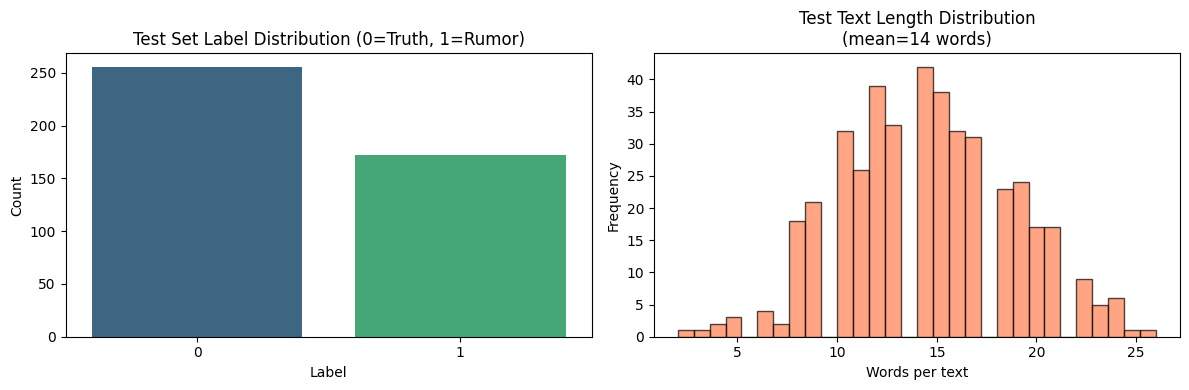

Test Set Statistics:
  Total samples: 428
  Truth (0): 256
  Rumor (1): 172
  Avg text length: 14 words


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Distribution on Test Set ---
if len(test_texts) > 0:
    df_test = pd.DataFrame({'text': test_texts, 'label': test_labels})

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    sns.countplot(x='label', data=df_test, palette='viridis')
    plt.title("Test Set Label Distribution (0=Truth, 1=Rumor)")
    plt.xlabel("Label")
    plt.ylabel("Count")

    test_lengths = [len(t.split()) for t in test_texts]

    plt.subplot(1, 2, 2)
    plt.hist(test_lengths, bins=30, color='coral', alpha=0.7, edgecolor='black')
    plt.title(f"Test Text Length Distribution\n(mean={np.mean(test_lengths):.0f} words)")
    plt.xlabel("Words per text")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

    print("Test Set Statistics:")
    print(f"  Total samples: {len(test_texts)}")
    print(f"  Truth (0): {sum(1 for l in test_labels if l == 0)}")
    print(f"  Rumor (1): {sum(1 for l in test_labels if l == 1)}")
    print(f"  Avg text length: {np.mean(test_lengths):.0f} words")
else:
    print("No test data loaded")

### 3.2 Load Pre-trained SLM Model
Load a pre-trained **RoBERTa-base** model that has been fine-tuned for fake news detection.
- **`IntegratedSLM`**: Wrapper class for inference and optional fine-tuning.
- **Model Location**: `model_SLM_twitter16` (generated from training notebook).
- For training/fine-tuning SLM, use the dedicated training notebook: `SLM_training_tw1516.ipynb`

In [19]:
# # --- Load Pre-trained SLM Model ---
# print(f"Loading pre-trained SLM from {MODEL_PATH}...")

# if os.path.exists(MODEL_PATH):
#     model = RobertaForSequenceClassification.from_pretrained(MODEL_PATH, num_labels=2)
#     tokenizer_slm = RobertaTokenizer.from_pretrained(MODEL_PATH)
#     print(f"Successfully loaded SLM from {MODEL_PATH}")
# else:
#     print(f"Pre-trained model not found at {MODEL_PATH}")
#     print("Using default RoBERTa-base model (untrained SLM)")
#     model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=2)
#     tokenizer_slm = RobertaTokenizer.from_pretrained("roberta-base")

# model.to(device)
# model.eval()

# print(f"Model loaded on device: {device}")

### 3.3 Integrated SLM Wrapper
- **`inference`**: Tra ve du doan (Real/Fake) va do tin cay (confidence score).
- **No retraining in MRCD notebook**: Notebook nay chi load model da huan luyen san va chay test/inference.

In [20]:
# --- Integrated SLM Wrapper ---
class IntegratedSLM:
    def __init__(self, model_path='/kaggle/input/models/chinhde/roberta-fine-v2/pytorch/default/1'):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        if not os.path.exists(model_path):
             print("Saved model not found. Using untrained base.")
             model_path = "roberta-base"
        else:
             print(f"Loading SLM from {model_path}")

        self.tokenizer = RobertaTokenizer.from_pretrained(model_path)
        self.model = RobertaForSequenceClassification.from_pretrained(model_path, num_labels=2)
        self.model.to(self.device)
        self.model.eval()

    def inference(self, text):
        clean_text = preprocess_text(text)
        inputs = self.tokenizer(clean_text, return_tensors='pt', truncation=True, max_length=128, padding='max_length')
        with torch.no_grad():
            outputs = self.model(inputs['input_ids'].to(self.device), inputs['attention_mask'].to(self.device))
            probs = F.softmax(outputs.logits, dim=1)
        conf, pred = torch.max(probs, dim=1)
        return pred.item(), conf.item(), probs[0].cpu().numpy()

    def finetune_on_clean(self, clean_samples, epochs=1, batch_size=32, lr=1e-5, weight_decay=1e-4):
        """Fine-tune SLM on pseudo-labeled D_clean after each round."""
        valid_samples = [
            s for s in clean_samples
            if s.get("text") is not None and s.get("label") in [0, 1]
        ]
        if not valid_samples:
            return {"trained": False, "reason": "no_valid_samples"}

        texts = [preprocess_text(s["text"]) for s in valid_samples]
        labels = [int(s["label"]) for s in valid_samples]

        dataset = FakeNewsDataset(texts, labels, self.tokenizer, max_len=128)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        optimizer = AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self.model.train()

        total_loss = 0.0
        total_steps = 0

        for _ in range(epochs):
            for batch in loader:
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels_t = batch['labels'].to(self.device)

                optimizer.zero_grad()
                outputs = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels_t,
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()

                total_loss += float(loss.item())
                total_steps += 1

        self.model.eval()
        avg_loss = total_loss / max(1, total_steps)
        return {
            "trained": True,
            "samples": len(valid_samples),
            "epochs": epochs,
            "batch_size": batch_size,
            "lr": lr,
            "weight_decay": weight_decay,
            "avg_loss": avg_loss,
        }

# Initialize Wrapper
slm_instance = IntegratedSLM()

Loading SLM from /kaggle/input/models/chinhde/roberta-fine-v2/pytorch/default/1


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

## 4. Triển khai Pipeline MRCD

### 4.1 Logic Pipeline MRCD (Inference-Only)
1. Data Preparation: đọc train + val để thống kê/phan tích; test set được dùng cho dự đoán và đánh giá.
2. Bootstrap Query Context: với mỗi query, truy xuất trước K_wiki, K_fact và Bing seed news (chỉ search, chưa BM25 với news corpus).
3. Demonstration Retrieval:
   - Round 1: BM25 trên (Bing seed news + static news corpus), demos được gán pseudo labels bằng semantic synonyms.
   - Round >= 2: ưu tiên BM25 trên D_clean; nếu D_clean không có/không lấy được demos thì fallback về (Bing seed news + static news corpus).
   - Label demo ở Round >= 2 được random trong tập synonym tương ứng với nhãn clean (REAL_NEWS_LABELS hoặc FAKE_NEWS_LABELS).
4. Knowledge Reuse: K_wiki và K_fact của từng query được giữ nguyên và dùng lại qua các vòng.
5. Round Inference: LLM dự đoán nhãn theo prompt (demos + K_wiki + K_fact), SLM dự đoán nhãn + confidence trên cùng đầu vào đã làm sạch.
6. Final Judgment: sau vòng N, các mẫu còn lại trong D_noisy được gán nhãn cuối bằng SLM để đảm bảo 100% dữ liệu được gán nhãn.

In [21]:
CONFIDENCE_THRESHOLD = 0.8
NUM_LOOP = 3
TOP_K_DEMOS = 4
FACT_TOP_K = 3
BOOTSTRAP_ENABLE_PARALLEL = True
BOOTSTRAP_MAX_WORKERS = min(16, max(4, (os.cpu_count() or 4) * 2))

ENABLE_SLM_FINETUNE = True
SLM_FINETUNE_EPOCHS = 1
SLM_FINETUNE_BATCH_SIZE = 32
SLM_FINETUNE_LR = 1e-5
SLM_FINETUNE_WEIGHT_DECAY = 1e-4
SLM_FINETUNE_MIN_SAMPLES = 16

def maybe_finetune_slm_on_clean(
    clean_pool: list,
    round_id: int,
    enable_slm_finetune: bool = ENABLE_SLM_FINETUNE,
    slm_finetune_epochs: int = SLM_FINETUNE_EPOCHS,
    slm_finetune_batch_size: int = SLM_FINETUNE_BATCH_SIZE,
    slm_finetune_lr: float = SLM_FINETUNE_LR,
    slm_finetune_weight_decay: float = SLM_FINETUNE_WEIGHT_DECAY,
    slm_finetune_min_samples: int = SLM_FINETUNE_MIN_SAMPLES,
):
    if not enable_slm_finetune:
        return {"trained": False, "reason": "disabled"}
    if len(clean_pool) < slm_finetune_min_samples:
        return {
            "trained": False,
            "reason": "insufficient_samples",
            "available_samples": len(clean_pool),
            "min_samples": slm_finetune_min_samples,
        }

    print(f"Fine-tuning SLM on D_clean after round {round_id} with {len(clean_pool)} samples...")
    stats = slm_instance.finetune_on_clean(
        clean_samples=clean_pool,
        epochs=slm_finetune_epochs,
        batch_size=slm_finetune_batch_size,
        lr=slm_finetune_lr,
        weight_decay=slm_finetune_weight_decay,
    )

    if stats.get("trained", False):
        print(
            f"SLM fine-tune done | round={round_id} samples={stats['samples']} "
            f"epochs={stats['epochs']} avg_loss={stats['avg_loss']:.4f}"
        )
    else:
        print(f"Skip SLM fine-tune at round {round_id}: {stats}")

    return stats

def to_clean_demo_label(binary_label: int) -> str:
    """Round 2+ uses class-consistent random synonym labels from clean pool."""
    if int(binary_label) == 0:
        candidate_labels = REAL_DEMO_LABELS if REAL_DEMO_LABELS else REAL_NEWS_LABELS
    else:
        candidate_labels = FAKE_DEMO_LABELS if FAKE_DEMO_LABELS else FAKE_NEWS_LABELS
    return random.choice(candidate_labels)

def retrieve_from_clean_pool(query: str, clean_pool: list, k: int = TOP_K_DEMOS):
    """Retrieve nearest demonstrations from D_clean using BM25 and clean labels."""
    if not clean_pool:
        return []

    cleaned_query = preprocess_text(query)
    corpus_items = [preprocess_text(item["text"]) for item in clean_pool]
    tokenized_corpus = [doc.lower().split() for doc in corpus_items]
    bm25 = BM25Okapi(tokenized_corpus)
    scores = bm25.get_scores(cleaned_query.lower().split())
    scored_indices = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)
    top_k = [idx for idx, _ in scored_indices[:k]]

    demos = []
    for idx in top_k:
        item = clean_pool[idx]
        clean_label = item.get("label", item.get("label_slm", 1))
        demos.append(
            {
                "text": preprocess_text(item["text"]),
                "label": to_clean_demo_label(clean_label),
                "source": "D_clean",
            }
        )
    return demos

def prefetch_query_context(
    text: str,
    demo_k: int = TOP_K_DEMOS,
    fact_top_k: int = FACT_TOP_K,
    reuse_knowledge_cache: bool = True,
    knowledge_cache_local: dict = None,
):
    """Bootstrap retrieval context before MRCD loop: K_wiki, K_fact, and Bing seed results."""
    cleaned_text = preprocess_text(text)

    if reuse_knowledge_cache:
        knowledge_bundle = get_cached_knowledge_bundle_local(
            cleaned_text,
            knowledge_cache_local,
            fact_top_k=fact_top_k,
        )
    else:
        knowledge_bundle = build_knowledge_bundle(cleaned_text, fact_top_k=fact_top_k)

    bing_seed_news = search_news(cleaned_text, max_results=demo_k)

    return {
        "text": cleaned_text,
        "knowledge_bundle": knowledge_bundle,
        "knowledge_text": knowledge_bundle.get("combined_text", "No info."),
        "bing_seed_news": bing_seed_news,
    }

def build_evidence_bundle(
    text: str,
    static_corpus: list,
    clean_pool: list,
    round_id: int,
    query_context: dict,
    demo_k: int = TOP_K_DEMOS,
):
    """Round 1: external+corpus BM25; Round 2+: D_clean BM25 with fallback when D_clean is empty."""
    cleaned_text = preprocess_text(text)
    knowledge_k = query_context.get("knowledge_text", "No info.")
    bing_seed_news = query_context.get("bing_seed_news", [])

    if round_id == 1:
        combined_corpus = static_corpus + bing_seed_news
        demos = retrieve_demonstrations(cleaned_text, combined_corpus, k=demo_k)
        retrieval_source = "external_prefetched"
    else:
        demos = retrieve_from_clean_pool(cleaned_text, clean_pool, k=demo_k)
        if demos:
            retrieval_source = "d_clean"
        else:
            combined_corpus = static_corpus + bing_seed_news
            demos = retrieve_demonstrations(cleaned_text, combined_corpus, k=demo_k)
            retrieval_source = "fallback_external_prefetched"

    return demos, knowledge_k, retrieval_source

def assess_with_llm_and_slm(text: str, demos: list, knowledge_k: str, llm):
    """Round inference from LLM and SLM with shared preprocessing."""
    cleaned_text = preprocess_text(text)
    prompt = build_classification_prompt(
        text=cleaned_text,
        knowledge_k=knowledge_k,
        demos=demos,
        real_labels=REAL_NEWS_LABELS,
        fake_labels=FAKE_NEWS_LABELS,
    )
    llm_resp = llm.generate_text(prompt, max_output_tokens=QWEN_MAX_OUTPUT_TOKENS_CLASSIFICATION)
    y_llm, matched_label = parse_binary_label(
        llm_resp,
        REAL_NEWS_LABELS,
        FAKE_NEWS_LABELS,
        default_fake=1,
        return_matched_label=True,
    )

    y_slm, conf_slm, slm_probs = slm_instance.inference(cleaned_text)
    return {
        "y_llm": y_llm,
        "y_slm": y_slm,
        "conf_slm": conf_slm,
        "slm_probs": slm_probs,
        "llm_raw": llm_resp,
        "llm_label_matched": matched_label,
    }

def split_clean_noisy(sample: dict, confidence_threshold: float):
    """Selection rule: agreement + confidence threshold."""
    return sample["label_llm"] == sample["label_slm"] and sample["conf_slm"] >= confidence_threshold

def finalize_remaining_noisy_with_slm(d_noisy: list):
    """Final judgment: force SLM labels for unresolved noisy samples."""
    finalized = []
    for sample in d_noisy:
        text = preprocess_text(sample["text"])
        y_slm, conf_slm, _ = slm_instance.inference(text)
        final_sample = dict(sample)
        final_sample["label"] = y_slm
        final_sample["label_final"] = y_slm
        final_sample["conf_slm_final"] = conf_slm
        final_sample["status"] = "finalized_by_slm"
        finalized.append(final_sample)
    return finalized

In [22]:
def run_mrcd_pipeline(
    events: List[str],
    max_rounds: int = NUM_LOOP,
    confidence_threshold: float = CONFIDENCE_THRESHOLD,
    reuse_knowledge_cache: bool = True,
    bootstrap_parallel: bool = BOOTSTRAP_ENABLE_PARALLEL,
    bootstrap_max_workers: int = BOOTSTRAP_MAX_WORKERS,
    enable_slm_finetune: bool = ENABLE_SLM_FINETUNE,
    slm_finetune_epochs: int = SLM_FINETUNE_EPOCHS,
    slm_finetune_batch_size: int = SLM_FINETUNE_BATCH_SIZE,
    slm_finetune_lr: float = SLM_FINETUNE_LR,
    slm_finetune_weight_decay: float = SLM_FINETUNE_WEIGHT_DECAY,
    slm_finetune_min_samples: int = SLM_FINETUNE_MIN_SAMPLES,
):
    print(f"Starting MRCD pipeline for {len(events)} events...")
    llm = get_llm()

    print("Loading news corpus (fact-checking base)...")
    static_corpus = load_news_corpus()
    print(f"Corpus loaded: {len(static_corpus)} documents")

    cleaned_events = [preprocess_text(e) for e in events]

    event_states = [
        {
            "event_id": idx,
            "text": text,
            "round": 0,
            "status": "unprocessed",
            "label": None,
            "label_llm": None,
            "label_slm": None,
            "conf_slm": None,
            "llm_raw": None,
            "llm_label_matched": None,
            "retrieval_source": None,
            "knowledge": None,
            "query_context": None,
        }
        for idx, text in enumerate(cleaned_events)
    ]

    d_clean = []
    d_noisy = []
    round_history = []
    finetune_history = []
    knowledge_cache_local = {}

    print("\n=== Bootstrap Retrieval Context: K_wiki + K_fact + Bing seed ===")
    unique_texts = list(dict.fromkeys([s["text"] for s in event_states]))
    context_map = {}

    if bootstrap_parallel and len(unique_texts) > 1:
        workers = max(1, int(bootstrap_max_workers))
        with ThreadPoolExecutor(max_workers=workers) as executor:
            future_to_text = {
                executor.submit(
                    prefetch_query_context,
                    text,
                    TOP_K_DEMOS,
                    FACT_TOP_K,
                    reuse_knowledge_cache,
                    knowledge_cache_local,
                ): text
                for text in unique_texts
            }

            for future in tqdm(as_completed(future_to_text), total=len(future_to_text), desc="Bootstrap Context"):
                text = future_to_text[future]
                try:
                    context_map[text] = future.result()
                except Exception:
                    context_map[text] = {
                        "text": text,
                        "knowledge_bundle": {"combined_text": "No info."},
                        "knowledge_text": "No info.",
                        "bing_seed_news": [],
                    }
    else:
        for text in tqdm(unique_texts, desc="Bootstrap Context"):
            context_map[text] = prefetch_query_context(
                text=text,
                demo_k=TOP_K_DEMOS,
                fact_top_k=FACT_TOP_K,
                reuse_knowledge_cache=reuse_knowledge_cache,
                knowledge_cache_local=knowledge_cache_local,
            )

    for state in event_states:
        qctx = context_map.get(state["text"])
        if qctx is None:
            qctx = {
                "text": state["text"],
                "knowledge_bundle": {"combined_text": "No info."},
                "knowledge_text": "No info.",
                "bing_seed_news": [],
            }
        state["query_context"] = qctx
        state["knowledge"] = qctx.get("knowledge_text", "No info.")

    round_id = 1
    print("\n=== Round 1: Retrieval + Assessment + Selection ===")
    for state in tqdm(event_states, desc="Round 1 Processing"):
        text = preprocess_text(state["text"])
        demos, knowledge_k, retrieval_source = build_evidence_bundle(
            text=text,
            static_corpus=static_corpus,
            clean_pool=d_clean,
            round_id=round_id,
            query_context=state["query_context"],
            demo_k=TOP_K_DEMOS,
        )
        assess = assess_with_llm_and_slm(text=text, demos=demos, knowledge_k=knowledge_k, llm=llm)

        state.update(
            {
                "round": round_id,
                "label": assess["y_llm"],
                "label_llm": assess["y_llm"],
                "label_slm": assess["y_slm"],
                "conf_slm": assess["conf_slm"],
                "llm_raw": assess["llm_raw"],
                "llm_label_matched": assess["llm_label_matched"],
                "retrieval_source": retrieval_source,
                "knowledge": knowledge_k,
            }
        )

        if split_clean_noisy(state, confidence_threshold):
            state["status"] = "clean"
            d_clean.append(state)
        else:
            state["status"] = "noisy"
            d_noisy.append(state)

    round_history.append(
        {
            "round": round_id,
            "clean_count": len(d_clean),
            "noisy_count": len(d_noisy),
        }
    )
    print(f"Round {round_id} summary -> Clean: {len(d_clean)}, Noisy: {len(d_noisy)}")

    ft_stats = maybe_finetune_slm_on_clean(
        clean_pool=d_clean,
        round_id=round_id,
        enable_slm_finetune=enable_slm_finetune,
        slm_finetune_epochs=slm_finetune_epochs,
        slm_finetune_batch_size=slm_finetune_batch_size,
        slm_finetune_lr=slm_finetune_lr,
        slm_finetune_weight_decay=slm_finetune_weight_decay,
        slm_finetune_min_samples=slm_finetune_min_samples,
    )
    finetune_history.append({"round": round_id, **ft_stats})

    round_id = 2
    while d_noisy and round_id <= max_rounds:
        print(f"\n=== Round {round_id}: Re-Assessment + SLM Fine-tune ===")

        next_noisy = []
        promoted_clean = 0

        for state in tqdm(d_noisy, desc=f"Round {round_id} Re-assess"):
            text = preprocess_text(state["text"])
            demos, knowledge_k, retrieval_source = build_evidence_bundle(
                text=text,
                static_corpus=static_corpus,
                clean_pool=d_clean,
                round_id=round_id,
                query_context=state["query_context"],
                demo_k=TOP_K_DEMOS,
            )
            assess = assess_with_llm_and_slm(text=text, demos=demos, knowledge_k=knowledge_k, llm=llm)

            state.update(
                {
                    "round": round_id,
                    "label": assess["y_llm"],
                    "label_llm": assess["y_llm"],
                    "label_slm": assess["y_slm"],
                    "conf_slm": assess["conf_slm"],
                    "llm_raw": assess["llm_raw"],
                    "llm_label_matched": assess["llm_label_matched"],
                    "retrieval_source": retrieval_source,
                    "knowledge": knowledge_k,
                }
            )

            if split_clean_noisy(state, confidence_threshold):
                state["status"] = f"clean@round{round_id}"
                d_clean.append(state)
                promoted_clean += 1
            else:
                state["status"] = f"noisy@round{round_id}"
                next_noisy.append(state)

        d_noisy = next_noisy
        round_history.append(
            {
                "round": round_id,
                "promoted_to_clean": promoted_clean,
                "clean_count": len(d_clean),
                "noisy_count": len(d_noisy),
            }
        )
        print(f"Round {round_id} summary -> +Clean: {promoted_clean}, Total Clean: {len(d_clean)}, Remaining Noisy: {len(d_noisy)}")

        ft_stats = maybe_finetune_slm_on_clean(
            clean_pool=d_clean,
            round_id=round_id,
            enable_slm_finetune=enable_slm_finetune,
            slm_finetune_epochs=slm_finetune_epochs,
            slm_finetune_batch_size=slm_finetune_batch_size,
            slm_finetune_lr=slm_finetune_lr,
            slm_finetune_weight_decay=slm_finetune_weight_decay,
            slm_finetune_min_samples=slm_finetune_min_samples,
        )
        finetune_history.append({"round": round_id, **ft_stats})

        round_id += 1

    finalized_noisy = []
    if d_noisy:
        print(f"\n=== Final Judgment: SLM force-labeling {len(d_noisy)} unresolved noisy samples ===")
        finalized_noisy = finalize_remaining_noisy_with_slm(d_noisy)
        for final_sample in finalized_noisy:
            final_sample["status"] = "finalized_by_slm"
        round_history.append(
            {
                "round": "final_judgment",
                "force_labeled_by_slm": len(finalized_noisy),
                "clean_count": len(d_clean),
                "remaining_noisy_after_final": 0,
            }
        )

    ordered_results = sorted(event_states, key=lambda x: x["event_id"])

    return {
        "results": ordered_results,
        "clean": d_clean,
        "noisy": d_noisy,
        "finalized_noisy": finalized_noisy,
        "history": round_history,
        "finetune_history": finetune_history,
        "knowledge_cache_size": len(knowledge_cache_local),
    }

## 5. DEMO và ĐÁNH GIÁ


In [23]:
# --- Load Data from CSV files ---
def load_data_from_csv(train_csv=TRAIN_CSV, val_csv=VAL_CSV, test_csv=TEST_CSV):
    """
    Load data from CSV files.
    - Merge train + val into one training set
    - Keep test set for evaluation/inference
    - Apply shared preprocessing for consistency
    """
    def load_csv_file(filepath):
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            return [], []

        try:
            df = pd.read_csv(filepath)
            texts = [preprocess_text(t) for t in df['content'].astype(str).tolist()]
            labels = [0 if label.lower() in ['true', 'non-rumor'] else 1 for label in df['label'].astype(str).tolist()]
            print(f"Loaded {len(texts)} samples from {filepath}")
            return texts, labels
        except Exception as e:
            print(f"Error loading {filepath}: {e}")
            return [], []

    print("Loading data from CSV files...")
    train_texts_raw, train_labels_raw = load_csv_file(train_csv)
    val_texts_raw, val_labels_raw = load_csv_file(val_csv)
    test_texts, test_labels = load_csv_file(test_csv)

    train_texts = train_texts_raw + val_texts_raw
    train_labels = train_labels_raw + val_labels_raw

    print(f"Merged train size (train+val): {len(train_texts)}")
    print(f"Test size: {len(test_texts)}")

    return train_texts, train_labels, test_texts, test_labels

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

def evaluate_and_plot(
    y_true,
    y_pred,
    labels=None,
    model_name="Model"
):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ===== Overall Metrics =====

    acc = accuracy_score(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = None

    # ===== Classification Report =====

    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=labels,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).T

    print(f"\n===== {model_name} =====")
    print(f"Accuracy: {acc:.4f}")

    if auc is not None:
        print(f"AUC     : {auc:.4f}")

    print("\n=== Precision / Recall / F1 cho từng class ===")
    print(report_df.round(4))

    # ===== Confusion Matrix =====

    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    plt.figure(figsize=(5,5))

    disp.plot(
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"Confusion Matrix - {model_name}")

    plt.tight_layout()
    plt.show()

    # ===== Return metrics =====

    metrics = {
        "accuracy": acc,
        "auc": auc,
        "classification_report": report_df,
        "confusion_matrix": cm
    }

    return metrics

Evaluating pre-trained SLM on test set...


Running inference:   0%|          | 0/428 [00:00<?, ?it/s]


===== Pre-trained SLM Baseline =====
Accuracy: 0.7991
AUC     : 0.7920

=== Precision / Recall / F1 cho từng class ===
              precision  recall  f1-score   support
Real/Truth       0.8346  0.8281    0.8314  256.0000
Fake/Rumor       0.7471  0.7558    0.7514  172.0000
accuracy         0.7991  0.7991    0.7991    0.7991
macro avg        0.7909  0.7920    0.7914  428.0000
weighted avg     0.7995  0.7991    0.7993  428.0000


<Figure size 500x500 with 0 Axes>

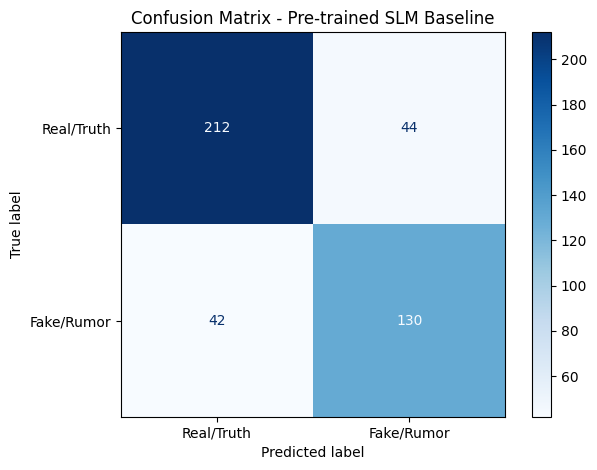


Average SLM confidence: 0.7535
Min confidence: 0.5025
Max confidence: 0.9825


In [25]:
# --- Test SLM Inference on Test Set ---
if len(test_texts) > 0:
    print("Evaluating pre-trained SLM on test set...")
    slm_preds = []
    slm_confs = []

    for text in tqdm(test_texts, desc="Running inference"):
        clean_text = preprocess_text(text)
        pred, conf, _ = slm_instance.inference(clean_text)
        slm_preds.append(pred)
        slm_confs.append(conf)

    labels = ["Real/Truth", "Fake/Rumor"]
    metrics_slm = evaluate_and_plot(test_labels, slm_preds, labels=labels, model_name="Pre-trained SLM Baseline")

    print(f"\nAverage SLM confidence: {np.mean(slm_confs):.4f}")
    print(f"Min confidence: {np.min(slm_confs):.4f}")
    print(f"Max confidence: {np.max(slm_confs):.4f}")
else:
    print("No test data available")

In [ ]:
# --- Evaluation on Emerging Events ---
if len(test_texts) > 0:
    flow_output = run_mrcd_pipeline(
        test_texts,
        reuse_knowledge_cache=True,
    )
    results = flow_output["results"]
    history = flow_output["history"]
    finalized_noisy = flow_output.get("finalized_noisy", [])
    knowledge_cache_size = flow_output.get("knowledge_cache_size", 0)

    print("\n=== Round History ===")
    for h in history:
        print(h)

    print(f"\nFinalized noisy by SLM: {len(finalized_noisy)}")
    print(f"In-run knowledge cache entries: {knowledge_cache_size}")

    y_true = test_labels[:len(results)]
    y_pred = [r["label"] for r in results]

    labels = ["Real", "Fake"]
    metrics_mrcd = evaluate_and_plot(y_true, y_pred, labels=labels, model_name="MRCD (Paper-Aligned Final)")

    print("\n=== Sample Predictions ===")
    for i, r in enumerate(results[:len(test_labels)]):
        truth = "Fake" if test_labels[i] == 1 else "Real"
        pred = "Fake" if r["label"] == 1 else "Real"
        print(f"[id={r['event_id']}] [{truth} -> {pred}] {r['text'][:50]}...")
else:
    print("No test data available.")

Starting MRCD pipeline for 428 events...
Loading news corpus (fact-checking base)...
 Loaded 120000 documents from AG News.
Corpus loaded: 120000 documents

=== Bootstrap Retrieval Context: K_wiki + K_fact + Bing seed ===


Bootstrap Context:   0%|          | 0/412 [00:00<?, ?it/s]

In [ ]:
if len(test_texts) > 0 and "metrics_slm" in globals() and "metrics_mrcd" in globals():
    def extract_prf(metrics_dict):
        report_df = metrics_dict.get("classification_report")
        if report_df is None or "weighted avg" not in report_df.index:
            return float("nan"), float("nan"), float("nan")
        return (
            float(report_df.loc["weighted avg", "precision"]),
            float(report_df.loc["weighted avg", "recall"]),
            float(report_df.loc["weighted avg", "f1-score"]),
        )

    slm_p, slm_r, slm_f1 = extract_prf(metrics_slm)
    mrcd_p, mrcd_r, mrcd_f1 = extract_prf(metrics_mrcd)

    comparison_df = pd.DataFrame([
        {
            "Model": "SLM Baseline",
            "Accuracy": float(metrics_slm["accuracy"]),
            "Precision": slm_p,
            "Recall": slm_r,
            "F1": slm_f1,
        },
        {
            "Model": "MRCD (Paper-Aligned Final)",
            "Accuracy": float(metrics_mrcd["accuracy"]),
            "Precision": mrcd_p,
            "Recall": mrcd_r,
            "F1": mrcd_f1,
        },
    ])

    print(comparison_df.round(4))

    ax = comparison_df.set_index("Model").plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
    ax.set_title("SLM Baseline vs MRCD Metrics (Test Set)")
    ax.set_ylabel("Score")
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Please run baseline and MRCD evaluation cells first.")